# Diabetes Prediction Using Machine Learning and Multilayer Perceptron

## End-to-End Diabetes Prediction System

This project develops a binary classification system for predicting diabetes
using clinical and demographic attributes.

The complete workflow includes:

- Dataset understanding
- Exploratory Data Analysis (EDA)
- Data quality analysis
- Missing-value handling
- Invalid and physiologically implausible value analysis
- Outlier analysis
- Feature engineering
- Feature selection
- Train-test splitting
- Feature scaling
- Multiple machine learning models
- Multilayer Perceptron (MLP)
- Hyperparameter tuning
- Model comparison
- Automatic model selection
- Final model evaluation
- Model saving
- Deployment

In [2]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

Python executable:
/usr/bin/python3


In [3]:
import joblib

print("joblib version:", joblib.__version__)
print("joblib imported successfully!")

joblib version: 1.5.3
joblib imported successfully!


In [4]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import time
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from IPython.display import display

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

warnings.filterwarnings("ignore")

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ============================================================
# DATASET FILE CHECK — GOOGLE COLAB
# ============================================================

import os

data_folder = "/content"

print("Files available in Colab:")
for file in os.listdir(data_folder):
    print("-", file)

Files available in Colab:
- .config
- diabetes.csv
- sample_data


In [6]:
# ============================================================
# LOAD DATASET
# ============================================================

DATA_PATH = "/content/diabetes.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head())

Dataset loaded successfully.
Rows    : 768
Columns : 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [7]:
# ============================================================
# DATASET PREVIEW
# ============================================================

print("First 5 records:")
display(df.head())

print("\nLast 5 records:")
display(df.tail())

First 5 records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Last 5 records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1
767,1,93,70.0,31,102.5,30.4,0.315,23,0


In [8]:
# ============================================================
# DATASET STRUCTURE
# ============================================================

print("Number of observations:", df.shape[0])
print("Number of features + target:", df.shape[1])

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

print("\nData types:")
display(df.dtypes)

Number of observations: 768
Number of features + target: 9

Column names:
1. Pregnancies
2. Glucose
3. BloodPressure
4. SkinThickness
5. Insulin
6. BMI
7. DiabetesPedigreeFunction
8. Age
9. Outcome

Data types:


,0
Pregnancies,int64
Glucose,int64
BloodPressure,float64
SkinThickness,int64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [9]:
# ============================================================
# DATASET INFORMATION
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [10]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [11]:
# ============================================================
# FEATURE TYPE IDENTIFICATION
# ============================================================

numerical_features = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Categorical features:
[]


In [12]:
# ============================================================
# TARGET VARIABLE
# ============================================================

TARGET = "Outcome"

print("Target variable:", TARGET)

print("\nTarget data type:")
print(df[TARGET].dtype)

print("\nTarget unique values:")
print(sorted(df[TARGET].unique()))

Target variable: Outcome

Target data type:
int64

Target unique values:
[np.int64(0), np.int64(1)]


In [13]:
# ============================================================
# TARGET CLASS DISTRIBUTION
# ============================================================

class_counts = df[TARGET].value_counts().sort_index()

class_percentages = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

target_summary.index = [
    "Non-Diabetic (0)",
    "Diabetic (1)"
]

display(target_summary)

,Count,Percentage
Non-Diabetic (0),500,65.1
Diabetic (1),268,34.9


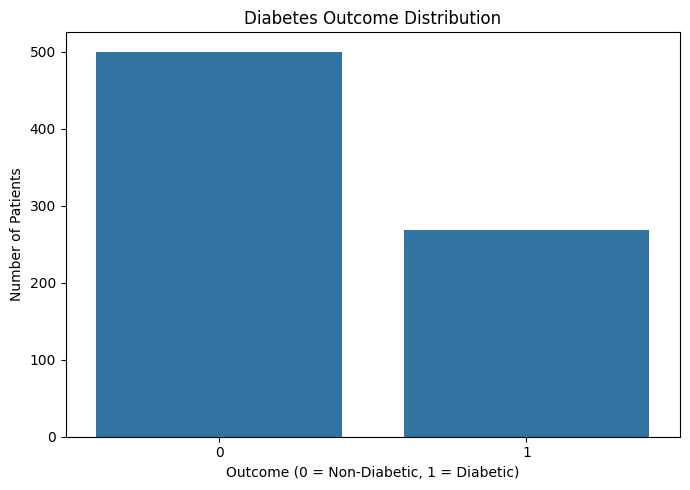

In [14]:
# ============================================================
# TARGET CLASS VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# DATA QUALITY: MISSING VALUES
# ============================================================

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

display(missing_summary)

,Missing Count,Missing Percentage
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


In [16]:
# ============================================================
# DATA QUALITY: DUPLICATE RECORDS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate records found.")
else:
    print("Duplicate records require further investigation.")

Number of duplicate rows: 0
No duplicate records found.


In [17]:
# ============================================================
# DATA QUALITY: ZERO-VALUE ANALYSIS
# ============================================================

zero_sensitive_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_summary = pd.DataFrame({
    "Zero Count": (df[zero_sensitive_features] == 0).sum(),
    "Zero Percentage": (
        (df[zero_sensitive_features] == 0).mean() * 100
    ).round(2)
})

display(zero_summary)

,Zero Count,Zero Percentage
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0


In [18]:
# ============================================================
# UNIVARIATE ANALYSIS
# ============================================================

univariate_summary = pd.DataFrame({
    "Mean": df[numerical_features].mean(),
    "Median": df[numerical_features].median(),
    "Std Dev": df[numerical_features].std(),
    "Minimum": df[numerical_features].min(),
    "Maximum": df[numerical_features].max(),
    "Skewness": df[numerical_features].skew()
})

display(univariate_summary.round(3))

,Mean,Median,Std Dev,Minimum,Maximum,Skewness
Pregnancies,3.845,3.000,3.370,0.000,17.00,0.902
Glucose,121.677,117.000,30.464,44.000,199.00,0.532
BloodPressure,72.389,72.000,12.106,24.000,122.00,0.141
SkinThickness,29.090,28.000,8.891,7.000,99.00,0.817
Insulin,141.754,102.500,89.101,14.000,846.00,3.028
BMI,32.435,32.050,6.880,18.200,67.10,0.606
DiabetesPedigreeFunction,0.472,0.372,0.331,0.078,2.42,1.920
Age,33.241,29.000,11.760,21.000,81.00,1.130
Outcome,0.349,0.000,0.477,0.000,1.00,0.635


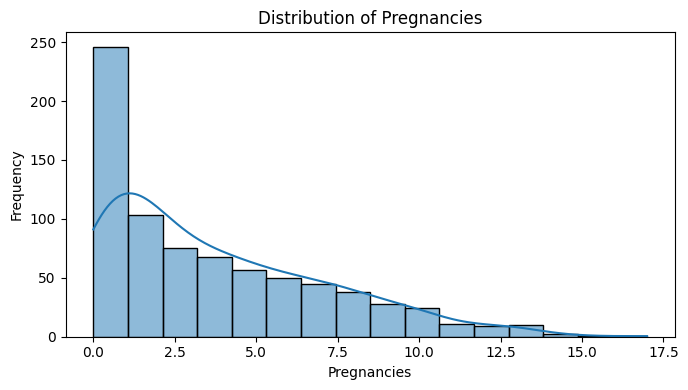

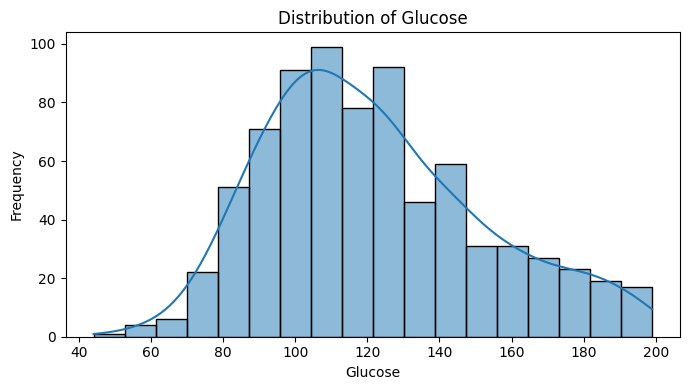

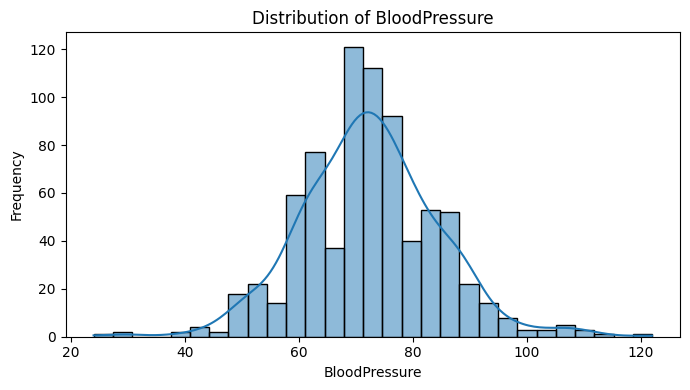

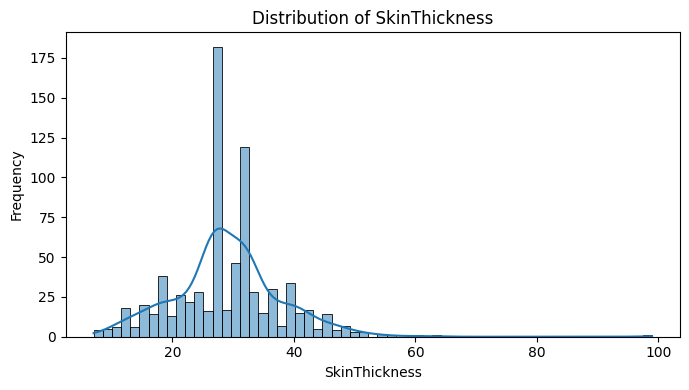

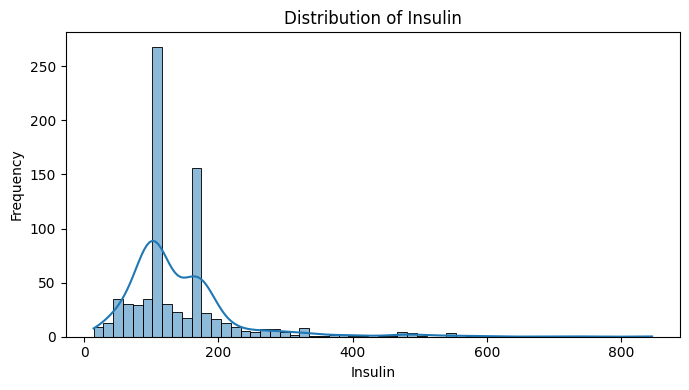

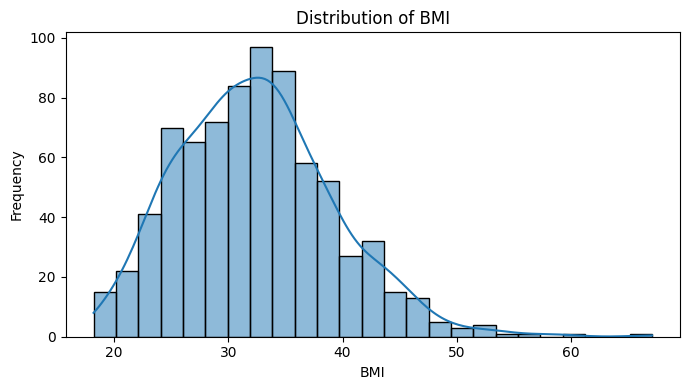

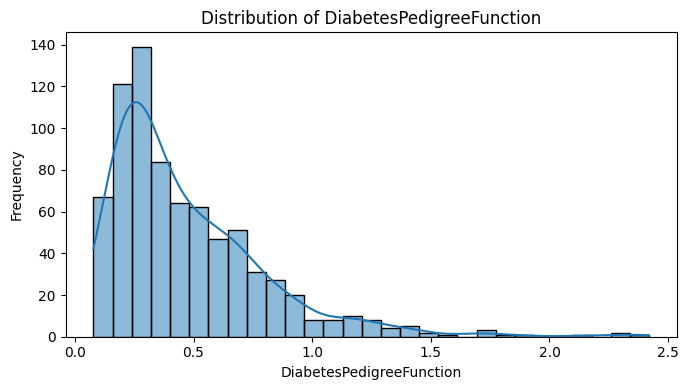

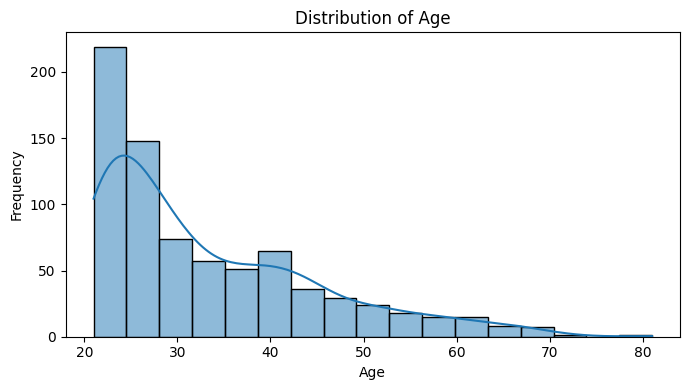

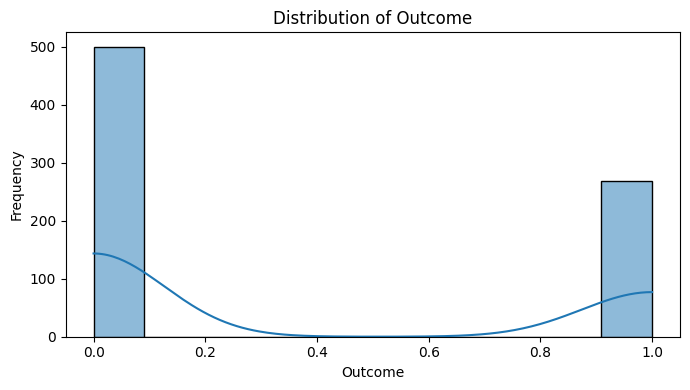

In [19]:
# ============================================================
# UNIVARIATE ANALYSIS: DISTRIBUTIONS
# ============================================================

for feature in numerical_features:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

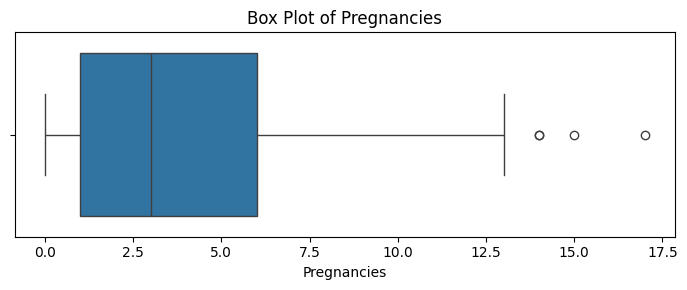

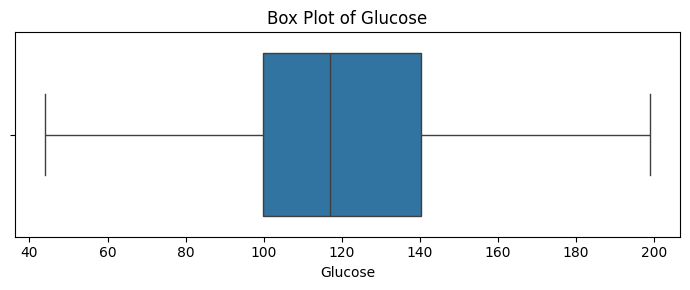

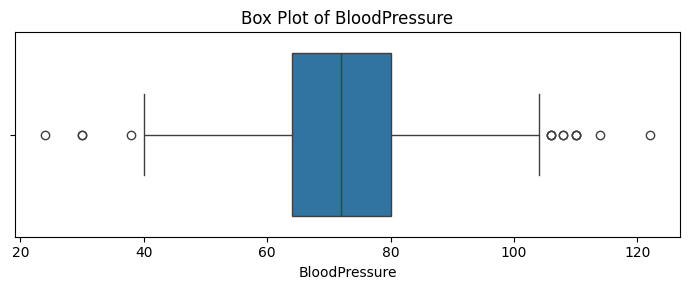

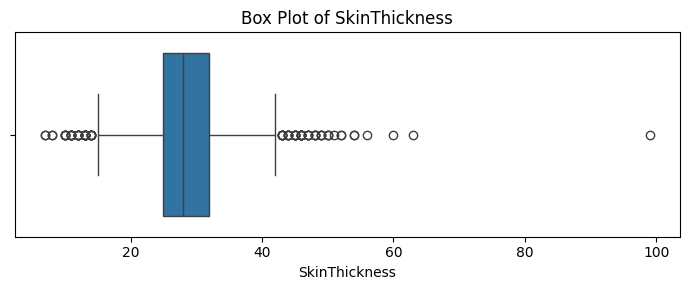

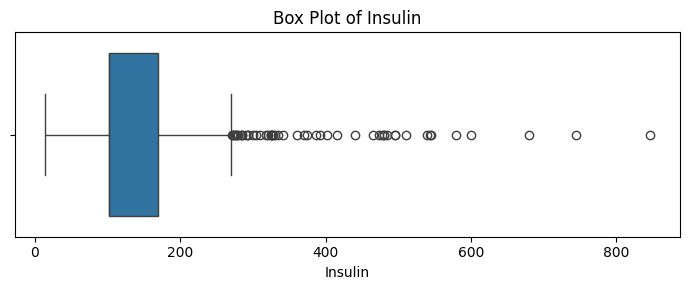

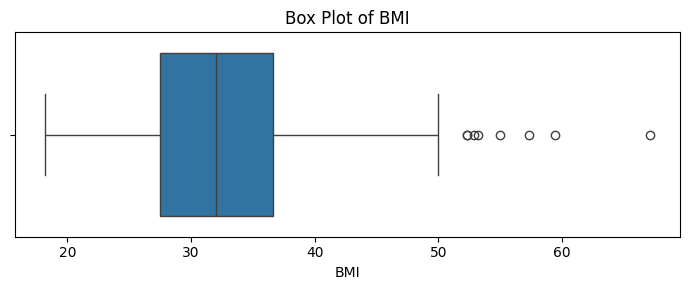

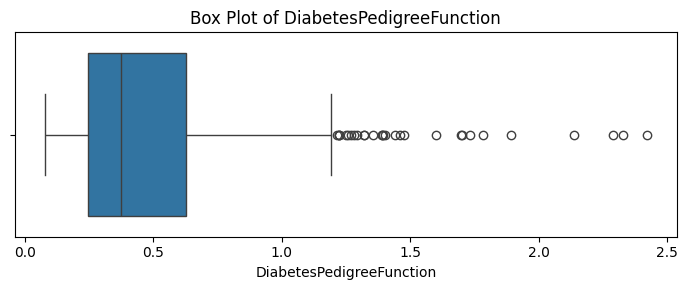

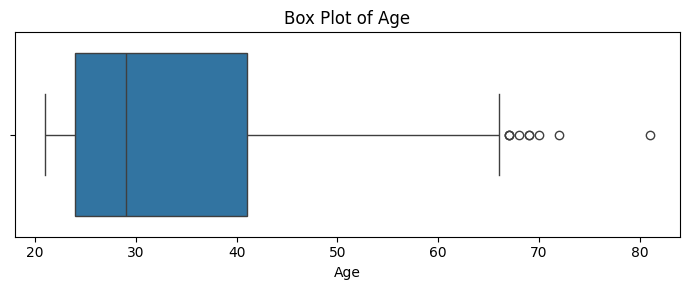

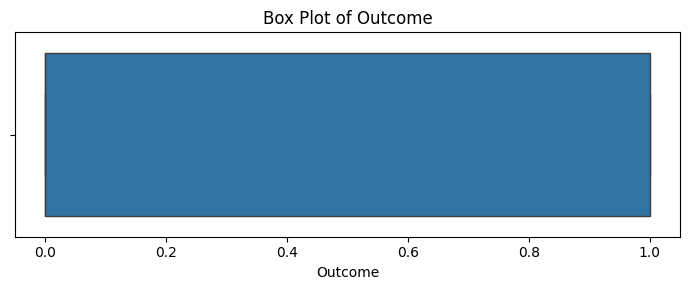

In [20]:
# ============================================================
# UNIVARIATE ANALYSIS: BOX PLOTS
# ============================================================

for feature in numerical_features:
    plt.figure(figsize=(7, 3))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(f"Box Plot of {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

In [21]:
# ============================================================
# OUTLIER ANALYSIS — IQR METHOD
# ============================================================

outlier_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

outlier_summary = []

for feature in outlier_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": len(outliers) / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary.round(3))

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Pregnancies,1.000,6.000,5.000,-6.50,13.50,4,0.521
1,Glucose,99.750,140.250,40.500,39.00,201.00,0,0.000
2,BloodPressure,64.000,80.000,16.000,40.00,104.00,14,1.823
3,SkinThickness,25.000,32.000,7.000,14.50,42.50,87,11.328
4,Insulin,102.500,169.500,67.000,2.00,270.00,51,6.641
5,BMI,27.500,36.600,9.100,13.85,50.25,8,1.042
6,DiabetesPedigreeFunction,0.244,0.626,0.382,-0.33,1.20,29,3.776
7,Age,24.000,41.000,17.000,-1.50,66.50,9,1.172


In [22]:
# ============================================================
# EXTREME VALUE INSPECTION
# ============================================================

for feature in outlier_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    print(f"\n{feature}")
    print("-" * 60)
    print("Number of outliers:", len(outliers))

    if len(outliers) > 0:
        print("Extreme values:")
        print(
            outliers[feature]
            .sort_values()
            .tolist()
        )


Pregnancies
------------------------------------------------------------
Number of outliers: 4
Extreme values:
[14, 14, 15, 17]

Glucose
------------------------------------------------------------
Number of outliers: 0

BloodPressure
------------------------------------------------------------
Number of outliers: 14
Extreme values:
[24.0, 30.0, 30.0, 38.0, 106.0, 106.0, 106.0, 108.0, 108.0, 110.0, 110.0, 110.0, 114.0, 122.0]

SkinThickness
------------------------------------------------------------
Number of outliers: 87
Extreme values:
[7, 7, 8, 8, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 43, 43, 43, 43, 43, 43, 44, 44, 44, 44, 44, 45, 45, 45, 45, 45, 45, 46, 46, 46, 46, 46, 46, 46, 46, 47, 47, 47, 47, 48, 48, 48, 48, 49, 49, 49, 50, 50, 50, 51, 52, 52, 54, 54, 56, 60, 63, 99]

Insulin
------------------------------------------------------------
Number of outliers: 51
Extreme values:


In [23]:
# ============================================================
# BIVARIATE ANALYSIS — GROUPED STATISTICS
# ============================================================

bivariate_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

grouped_statistics = df.groupby("Outcome")[bivariate_features].agg(
    ["mean", "median", "std"]
)

display(grouped_statistics.round(3))

Pregnancies                Glucose                BloodPressure  \
               mean median    std     mean median     std          mean   
Outcome                                                                   
0             3.298    2.0  3.017  110.622  107.0  24.704        70.844   
1             4.866    4.0  3.741  142.302  140.0  29.489        75.272   

                       SkinThickness                Insulin                 \
        median     std          mean median    std     mean median     std   
Outcome                                                                      
0         70.0  11.929        27.170   27.0  8.517  117.172  102.5  75.685   
1         74.5  11.927        32.672   32.0  8.469  187.616  169.5  94.114   

            BMI               DiabetesPedigreeFunction                   Age  \
           mean median    std                     mean median    std    mean   
Outcome                                                                        
0        30.846   30.1  6.502                     0.43  0.336  0.299  31.190   
1        35.399   34.3  6.591                     0.55  0.449  0.372  37.067   

                        
        median     std  
Outcome                 
0         27.0  11.668  
1         36.0  10.968

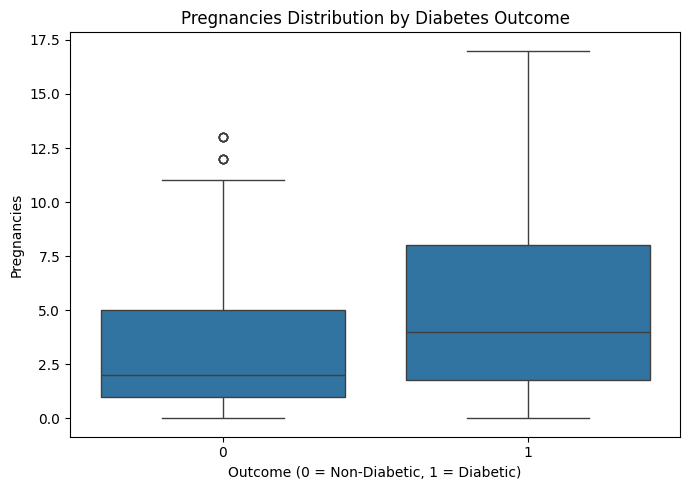

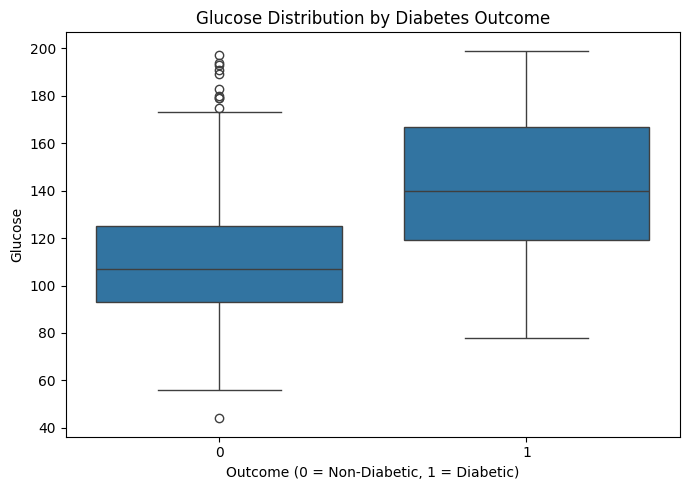

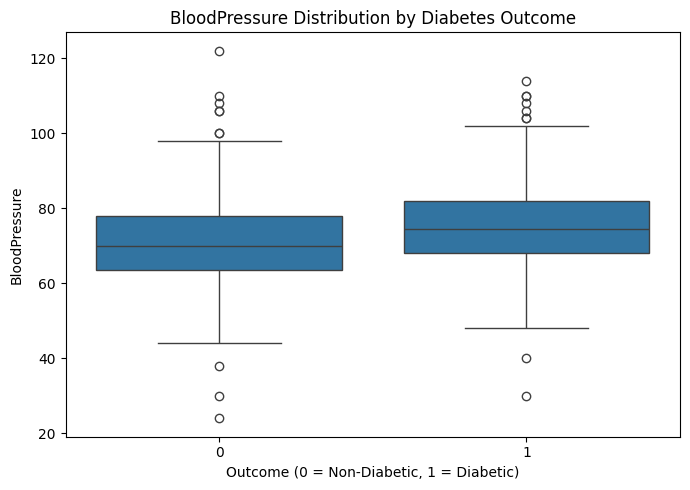

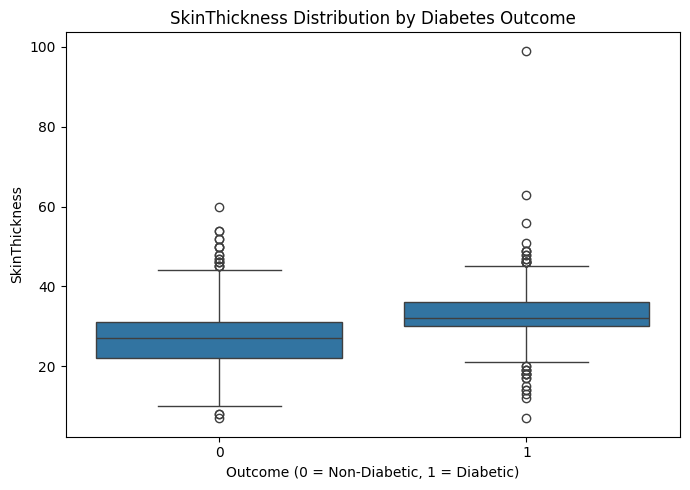

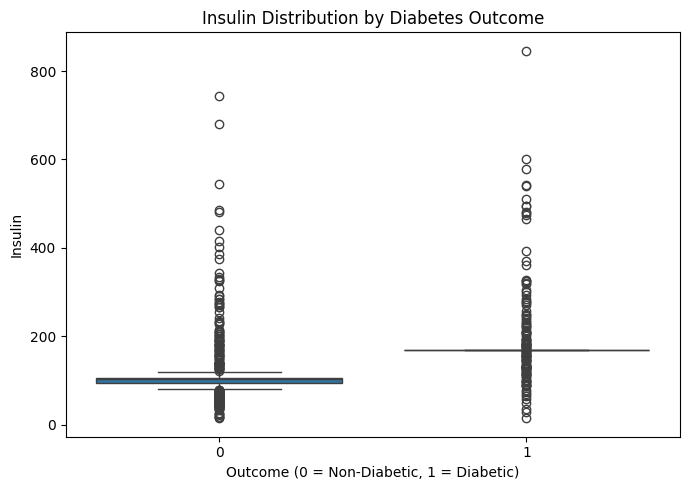

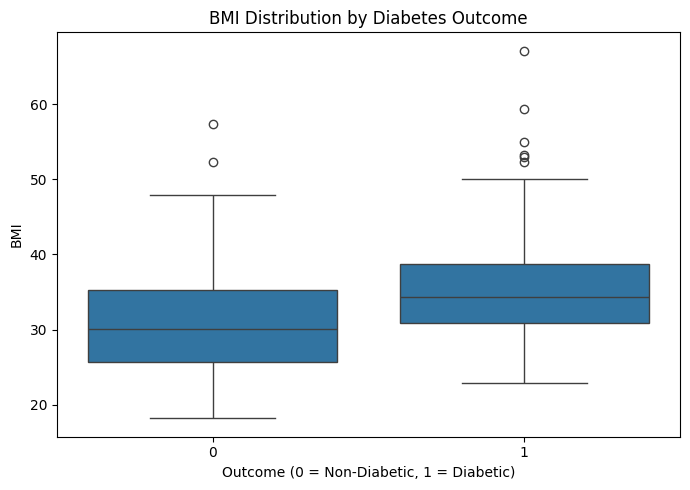

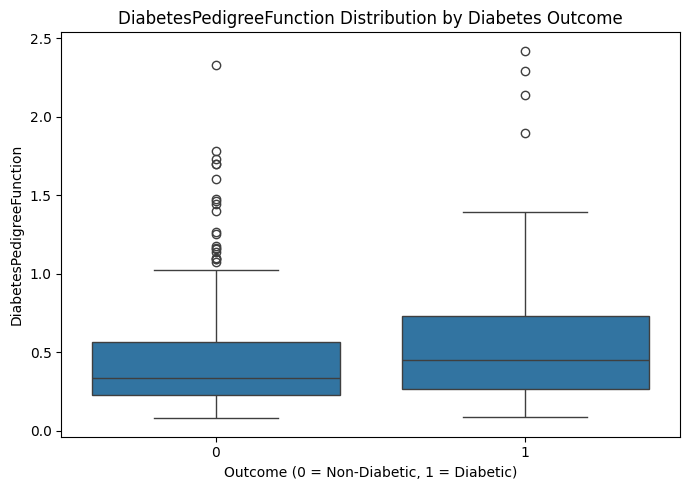

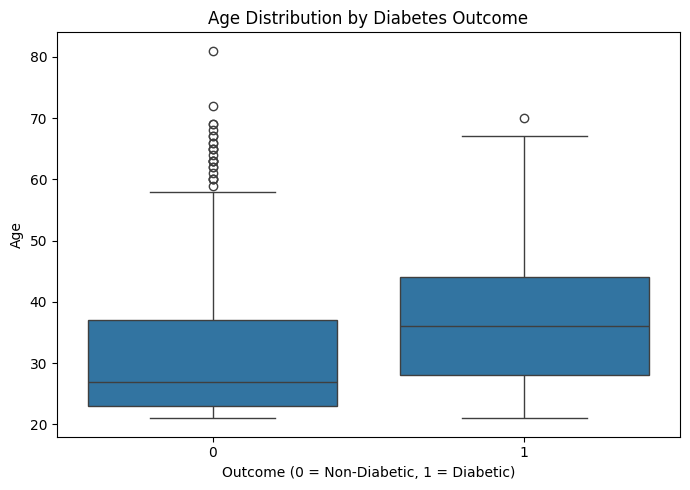

In [24]:
# ============================================================
# BIVARIATE ANALYSIS — FEATURES VS OUTCOME
# ============================================================

for feature in bivariate_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="Outcome",
        y=feature
    )

    plt.title(f"{feature} Distribution by Diabetes Outcome")
    plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

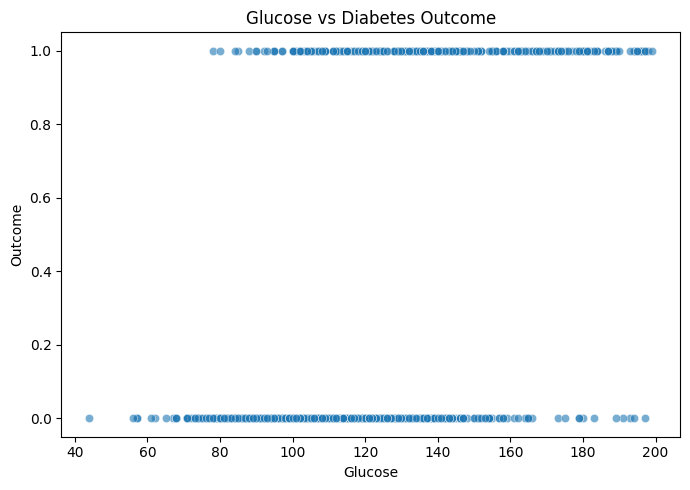

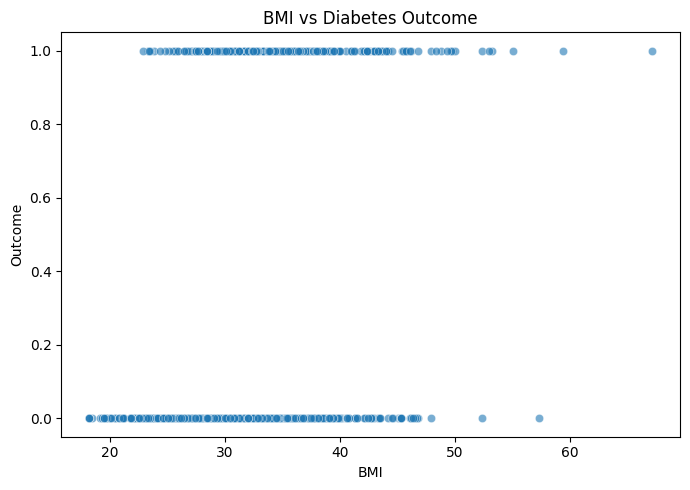

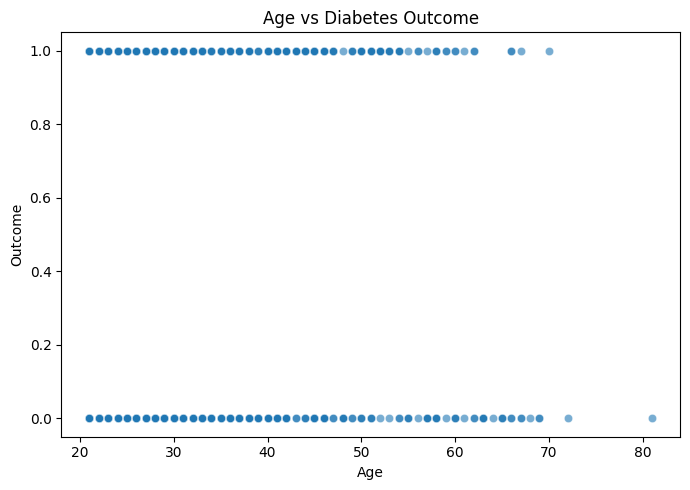

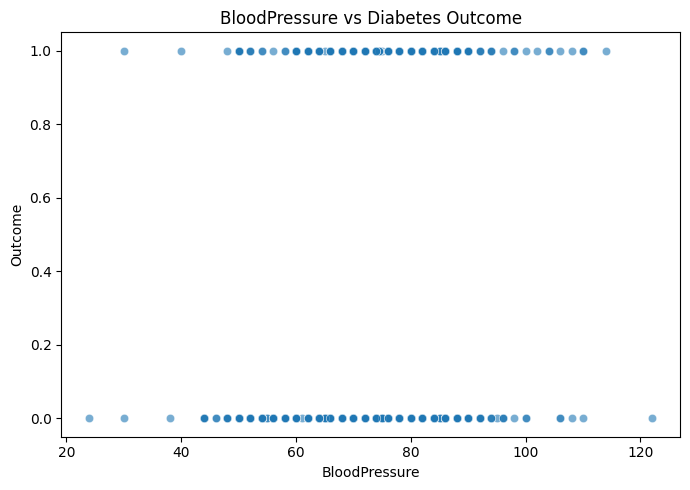

In [25]:
# ============================================================
# BIVARIATE ANALYSIS — SCATTER PLOTS
# ============================================================

scatter_features = [
    "Glucose",
    "BMI",
    "Age",
    "BloodPressure"
]

for feature in scatter_features:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=df,
        x=feature,
        y="Outcome",
        alpha=0.6
    )

    plt.title(f"{feature} vs Diabetes Outcome")
    plt.xlabel(feature)
    plt.ylabel("Outcome")

    plt.tight_layout()
    plt.show()

In [26]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_matrix = df.corr(numeric_only=True)

display(correlation_matrix.round(3))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000,0.130,0.209,0.089,0.059,0.024,-0.034,0.544,0.222
Glucose,0.130,1.000,0.225,0.229,0.490,0.236,0.138,0.269,0.496
BloodPressure,0.209,0.225,1.000,0.199,0.070,0.286,-0.001,0.325,0.174
SkinThickness,0.089,0.229,0.199,1.000,0.200,0.566,0.106,0.130,0.295
Insulin,0.059,0.490,0.070,0.200,1.000,0.238,0.147,0.124,0.377
BMI,0.024,0.236,0.286,0.566,0.238,1.000,0.153,0.028,0.316
DiabetesPedigreeFunction,-0.034,0.138,-0.001,0.106,0.147,0.153,1.000,0.034,0.174
Age,0.544,0.269,0.325,0.130,0.124,0.028,0.034,1.000,0.238
Outcome,0.222,0.496,0.174,0.295,0.377,0.316,0.174,0.238,1.000


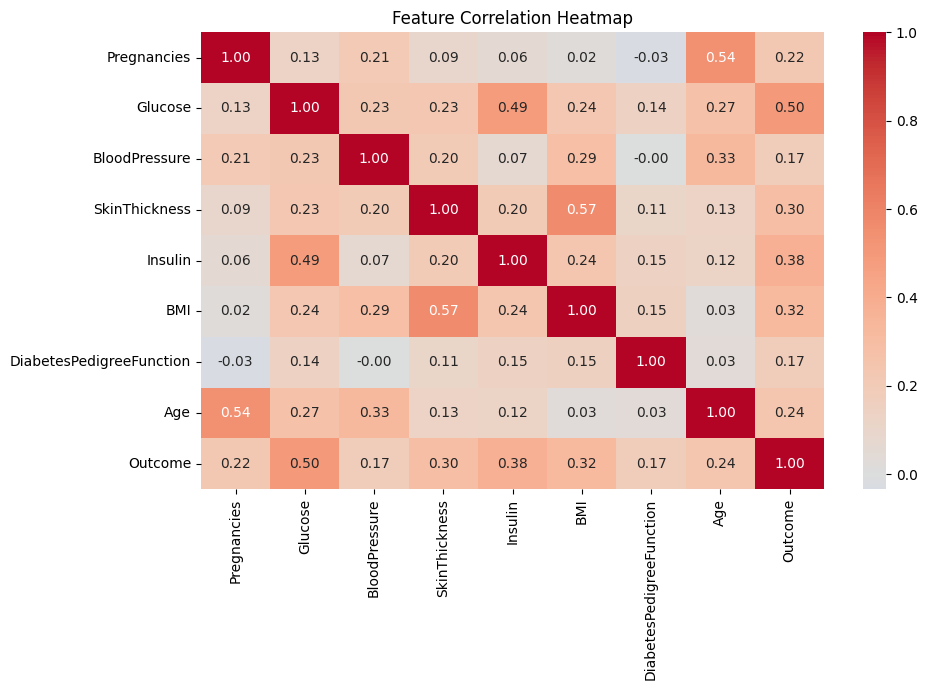

In [27]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# PHYSIOLOGICAL / PLAUSIBILITY CHECK
# ============================================================

plausibility_ranges = {
    "Glucose": (40, 250),
    "BloodPressure": (30, 150),
    "SkinThickness": (0, 100),
    "Insulin": (0, 900),
    "BMI": (10, 70),
    "Age": (18, 100),
    "Pregnancies": (0, 20),
    "DiabetesPedigreeFunction": (0, 3)
}

plausibility_results = []

for feature, (lower, upper) in plausibility_ranges.items():

    invalid = df[
        (df[feature] < lower) |
        (df[feature] > upper)
    ]

    plausibility_results.append({
        "Feature": feature,
        "Expected Lower": lower,
        "Expected Upper": upper,
        "Invalid Count": len(invalid),
        "Invalid Percentage": round(
            len(invalid) / len(df) * 100, 2
        )
    })

plausibility_results = pd.DataFrame(plausibility_results)

display(plausibility_results)

,Feature,Expected Lower,Expected Upper,Invalid Count,Invalid Percentage
0,Glucose,40,250,0,0.00
1,BloodPressure,30,150,1,0.13
2,SkinThickness,0,100,0,0.00
3,Insulin,0,900,0,0.00
4,BMI,10,70,0,0.00
5,Age,18,100,0,0.00
6,Pregnancies,0,20,0,0.00
7,DiabetesPedigreeFunction,0,3,0,0.00


In [29]:
# ============================================================
# INSPECT POTENTIALLY IMPLAUSIBLE OBSERVATIONS
# ============================================================

for feature, (lower, upper) in plausibility_ranges.items():

    invalid = df[
        (df[feature] < lower) |
        (df[feature] > upper)
    ]

    if len(invalid) > 0:
        print(f"\n{feature}")
        print("-" * 60)
        print(invalid[[feature, "Outcome"]].to_string())


BloodPressure
------------------------------------------------------------
     BloodPressure  Outcome
597           24.0        0


In [30]:
# ============================================================
# FEATURE ENGINEERING — INVESTIGATION
# ============================================================

# Work on a copy so the original dataset remains unchanged
df_fe = df.copy()

# ------------------------------------------------------------
# Age groups
# ------------------------------------------------------------

df_fe["AgeGroup"] = pd.cut(
    df_fe["Age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ]
)

# ------------------------------------------------------------
# BMI categories
# ------------------------------------------------------------

df_fe["BMICategory"] = pd.cut(
    df_fe["BMI"],
    bins=[0, 18.5, 25, 30, 35, 100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obesity_Class_I",
        "Obesity_Class_II+"
    ]
)

# ------------------------------------------------------------
# Glucose categories
# ------------------------------------------------------------

df_fe["GlucoseCategory"] = pd.cut(
    df_fe["Glucose"],
    bins=[0, 100, 126, 200, 300],
    labels=[
        "Normal",
        "Prediabetic_Range",
        "High",
        "Very_High"
    ]
)

print("Feature engineering investigation completed.")

display(
    df_fe[
        [
            "Age",
            "AgeGroup",
            "BMI",
            "BMICategory",
            "Glucose",
            "GlucoseCategory",
            "Outcome"
        ]
    ].head(10)
)

Feature engineering investigation completed.


,Age,AgeGroup,BMI,BMICategory,Glucose,GlucoseCategory,Outcome
0,50,46-55,33.6,Obesity_Class_I,148,High,1
1,31,26-35,26.6,Overweight,85,Normal,0
2,32,26-35,23.3,Normal,183,High,1
3,21,18-25,28.1,Overweight,89,Normal,0
4,33,26-35,43.1,Obesity_Class_II+,137,High,1
5,30,26-35,25.6,Overweight,116,Prediabetic_Range,0
6,26,26-35,31.0,Obesity_Class_I,78,Normal,1
7,29,26-35,35.3,Obesity_Class_II+,115,Prediabetic_Range,0
8,53,46-55,30.5,Obesity_Class_I,197,High,1
9,54,46-55,34.3,Obesity_Class_I,125,Prediabetic_Range,1


In [31]:
# ============================================================
# FEATURE SELECTION — CORRELATION WITH TARGET
# ============================================================

target_correlations = (
    df.corr(numeric_only=True)["Outcome"]
    .drop("Outcome")
    .sort_values(key=abs, ascending=False)
)

print("Correlation of features with diabetes outcome:")
display(target_correlations.to_frame("Correlation").round(3))

Correlation of features with diabetes outcome:


,Correlation
Glucose,0.496
Insulin,0.377
BMI,0.316
SkinThickness,0.295
Age,0.238
Pregnancies,0.222
BloodPressure,0.174
DiabetesPedigreeFunction,0.174


In [32]:
# ============================================================
# MULTICOLLINEARITY ANALYSIS — VIF
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=["Outcome"]).copy()

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

display(vif_data.sort_values("VIF", ascending=False).round(3))

,Feature,VIF
5,BMI,34.624
2,BloodPressure,32.328
1,Glucose,23.004
3,SkinThickness,17.724
7,Age,14.323
4,Insulin,4.774
0,Pregnancies,3.273
6,DiabetesPedigreeFunction,3.153


In [33]:
# ============================================================
# EXPLORATORY FEATURE IMPORTANCE
# ============================================================

from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

rf_exploration = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE
)

rf_exploration.fit(X, y)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_exploration.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.round(4))

,Feature,Importance
4,Insulin,0.3610
1,Glucose,0.1578
3,SkinThickness,0.1450
5,BMI,0.0875
7,Age,0.0864
6,DiabetesPedigreeFunction,0.0653
2,BloodPressure,0.0492
0,Pregnancies,0.0478


In [34]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# ------------------------------------------------------------
# STEP 1: Separate final TEST set
# 80% development data + 20% final test data
# ------------------------------------------------------------

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# ------------------------------------------------------------
# STEP 2: Split development data into TRAIN + VALIDATION
# 80% of 80% = 64% total
# 20% of 80% = 16% total
# ------------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_dev
)

# ============================================================
# DISPLAY DATASET SIZES
# ============================================================

print("=" * 60)
print("DATASET SPLIT")
print("=" * 60)

print(f"Total observations     : {len(df)}")

print("\nTraining set:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nValidation set:")
print(f"X_val  : {X_val.shape}")
print(f"y_val  : {y_val.shape}")

print("\nTest set:")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

# ============================================================
# CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

distribution = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).sort_index()

distribution.index = ["Non-Diabetic (0)", "Diabetic (1)"]

display((distribution * 100).round(2))

DATASET SPLIT
Total observations     : 768

Training set:
X_train: (491, 8)
y_train: (491,)

Validation set:
X_val  : (123, 8)
y_val  : (123,)

Test set:
X_test : (154, 8)
y_test : (154,)

CLASS DISTRIBUTION


,Train,Validation,Test
Non-Diabetic (0),65.17,65.04,64.94
Diabetic (1),34.83,34.96,35.06


In [35]:
# ============================================================
# ZERO-VALUE ANALYSIS AFTER DATA SPLIT
# ============================================================

zero_sensitive_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_split_summary = pd.DataFrame({
    "Training Zeros": (X_train[zero_sensitive_features] == 0).sum(),
    "Validation Zeros": (X_val[zero_sensitive_features] == 0).sum(),
    "Test Zeros": (X_test[zero_sensitive_features] == 0).sum()
})

display(zero_split_summary)

,Training Zeros,Validation Zeros,Test Zeros
Glucose,0,0,0
BloodPressure,0,0,0
SkinThickness,0,0,0
Insulin,0,0,0
BMI,0,0,0


In [36]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Features where zero represents a suspicious/missing measurement
zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Work on copies so original data remains unchanged
X_train_clean = X_train.copy()
X_val_clean = X_val.copy()
X_test_clean = X_test.copy()

# Convert physiologically suspicious zeros to NaN
for feature in zero_as_missing:
    X_train_clean[feature] = X_train_clean[feature].replace(0, np.nan)
    X_val_clean[feature] = X_val_clean[feature].replace(0, np.nan)
    X_test_clean[feature] = X_test_clean[feature].replace(0, np.nan)

print("Suspicious zero values converted to NaN.")

Suspicious zero values converted to NaN.


In [37]:
# ============================================================
# MEDIAN IMPUTATION
# ============================================================

imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_clean),
    columns=X_train_clean.columns,
    index=X_train_clean.index
)

X_val_imputed = pd.DataFrame(
    imputer.transform(X_val_clean),
    columns=X_val_clean.columns,
    index=X_val_clean.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_clean),
    columns=X_test_clean.columns,
    index=X_test_clean.index
)

print("Median imputation completed.")
print("Imputer fitted only on training data.")

Median imputation completed.
Imputer fitted only on training data.


In [38]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train_imputed.columns,
    index=X_train_imputed.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_imputed),
    columns=X_val_imputed.columns,
    index=X_val_imputed.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

print("Feature scaling completed.")
print("StandardScaler fitted only on training data.")

Feature scaling completed.
StandardScaler fitted only on training data.


In [39]:
# ============================================================
# HANDLE PHYSIOLOGICALLY IMPLAUSIBLE VALUES
# ============================================================

# Based on the plausibility ranges investigated during EDA
plausibility_ranges = {
    "Glucose": (40, 250),
    "BloodPressure": (30, 150),
    "SkinThickness": (0, 100),
    "Insulin": (0, 900),
    "BMI": (10, 70),
    "Age": (18, 100),
    "Pregnancies": (0, 20),
    "DiabetesPedigreeFunction": (0, 3)
}

for feature, (lower, upper) in plausibility_ranges.items():

    X_train_clean.loc[
        (X_train_clean[feature] < lower) |
        (X_train_clean[feature] > upper),
        feature
    ] = np.nan

    X_val_clean.loc[
        (X_val_clean[feature] < lower) |
        (X_val_clean[feature] > upper),
        feature
    ] = np.nan

    X_test_clean.loc[
        (X_test_clean[feature] < lower) |
        (X_test_clean[feature] > upper),
        feature
    ] = np.nan


print("Physiologically implausible values converted to NaN.")

Physiologically implausible values converted to NaN.


In [40]:
# ============================================================
# MEDIAN IMPUTATION
# ============================================================

imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_clean),
    columns=X_train_clean.columns,
    index=X_train_clean.index
)

X_val_imputed = pd.DataFrame(
    imputer.transform(X_val_clean),
    columns=X_val_clean.columns,
    index=X_val_clean.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_clean),
    columns=X_test_clean.columns,
    index=X_test_clean.index
)

print("Median imputation completed.")
print("Imputer fitted only on training data.")

Median imputation completed.
Imputer fitted only on training data.


In [41]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train_imputed.columns,
    index=X_train_imputed.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_imputed),
    columns=X_val_imputed.columns,
    index=X_val_imputed.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

print("Feature scaling completed.")
print("StandardScaler fitted only on training data.")

Feature scaling completed.
StandardScaler fitted only on training data.


In [42]:
# ============================================================
# BASELINE MODEL DEVELOPMENT
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

import time

print("Model libraries imported successfully.")

Model libraries imported successfully.


In [43]:
# ============================================================
# BASELINE MACHINE LEARNING MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

print("Baseline models created:")
for name in models:
    print("-", name)

Baseline models created:
- Logistic Regression
- K-Nearest Neighbors
- Support Vector Machine
- Decision Tree
- Random Forest
- Gradient Boosting


In [44]:
# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model(model, X_train, y_train, X_val, y_val):

    start_time = time.time()

    # Train
    model.fit(X_train, y_train)

    training_time = time.time() - start_time

    # Validation predictions
    y_pred = model.predict(X_val)

    # Probability / decision scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_val)[:, 1]
    else:
        y_score = model.decision_function(X_val)

    # Metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_val, y_score)

    cm = confusion_matrix(y_val, y_pred)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "Training Time (s)": training_time,
        "Confusion Matrix": cm
    }

In [45]:
# ============================================================
# TRAIN AND COMPARE BASELINE ML MODELS
# ============================================================

baseline_results = {}

for name, model in models.items():

    print(f"\nTraining: {name}")

    results = evaluate_model(
        model,
        X_train_scaled,
        y_train,
        X_val_scaled,
        y_val
    )

    baseline_results[name] = results

    print(f"Accuracy : {results['Accuracy']:.4f}")
    print(f"Precision: {results['Precision']:.4f}")
    print(f"Recall   : {results['Recall']:.4f}")
    print(f"F1-score : {results['F1']:.4f}")
    print(f"ROC-AUC  : {results['ROC-AUC']:.4f}")


Training: Logistic Regression
Accuracy : 0.8293
Precision: 0.8235
Recall   : 0.6512
F1-score : 0.7273
ROC-AUC  : 0.9096

Training: K-Nearest Neighbors
Accuracy : 0.8455
Precision: 0.7857
Recall   : 0.7674
F1-score : 0.7765
ROC-AUC  : 0.9023

Training: Support Vector Machine
Accuracy : 0.8780
Precision: 0.7917
Recall   : 0.8837
F1-score : 0.8352
ROC-AUC  : 0.9422

Training: Decision Tree
Accuracy : 0.8130
Precision: 0.6923
Recall   : 0.8372
F1-score : 0.7579
ROC-AUC  : 0.8186

Training: Random Forest
Accuracy : 0.9024
Precision: 0.8039
Recall   : 0.9535
F1-score : 0.8723
ROC-AUC  : 0.9592

Training: Gradient Boosting
Accuracy : 0.8862
Precision: 0.7843
Recall   : 0.9302
F1-score : 0.8511
ROC-AUC  : 0.9672


In [46]:
# ============================================================
# BASELINE MODEL COMPARISON
# ============================================================

comparison_data = []

for name, result in baseline_results.items():

    comparison_data.append({
        "Model": name,
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1": result["F1"],
        "ROC-AUC": result["ROC-AUC"],
        "Training Time (s)": result["Training Time (s)"]
    })

baseline_comparison = pd.DataFrame(comparison_data)

baseline_comparison = baseline_comparison.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    baseline_comparison.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "Training Time (s)": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Gradient Boosting,0.886,0.784,0.930,0.851,0.967,0.2381
1,Random Forest,0.902,0.804,0.953,0.872,0.959,0.6249
2,Support Vector Machine,0.878,0.792,0.884,0.835,0.942,0.0679
3,Logistic Regression,0.829,0.824,0.651,0.727,0.910,0.0121
4,K-Nearest Neighbors,0.846,0.786,0.767,0.776,0.902,0.0043
5,Decision Tree,0.813,0.692,0.837,0.758,0.819,0.0074


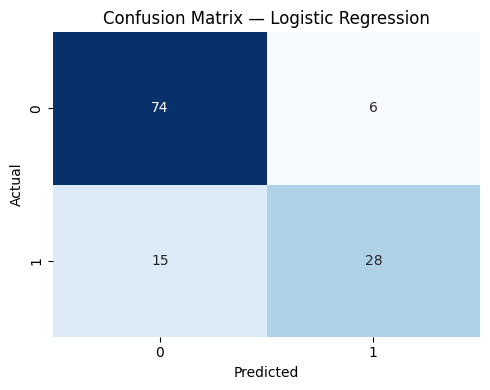

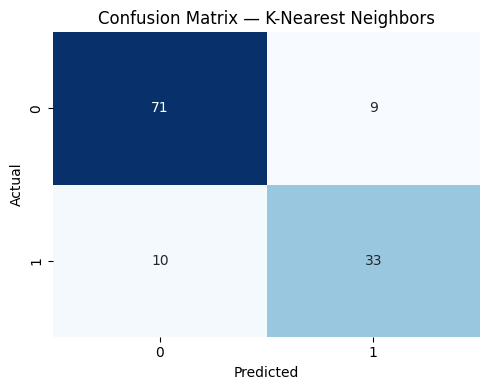

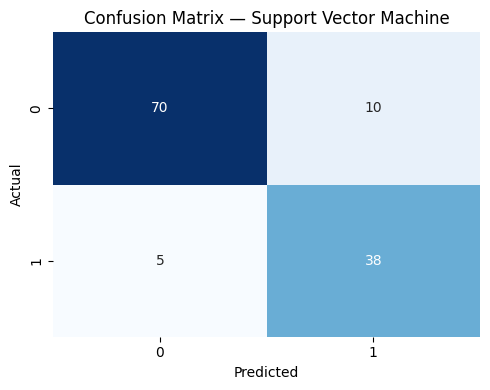

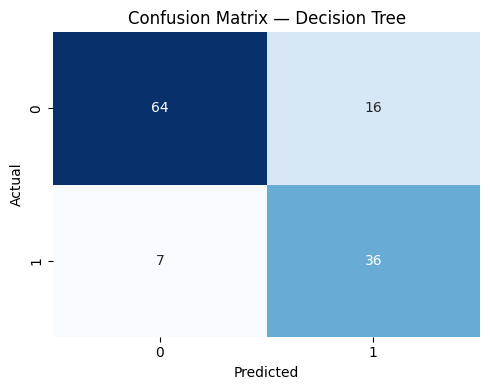

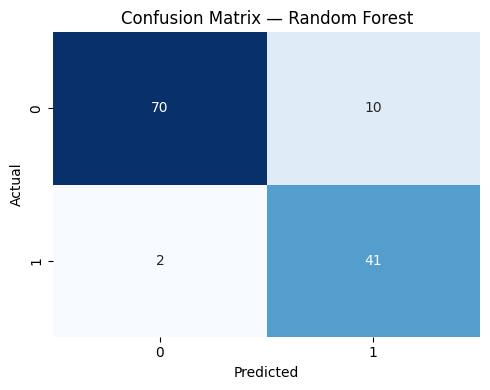

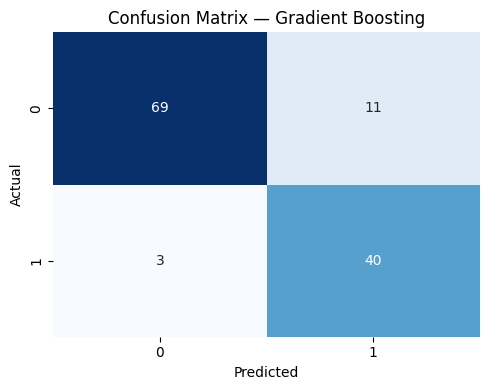

In [47]:
# ============================================================
# CONFUSION MATRICES — BASELINE MODELS
# ============================================================

for name, result in baseline_results.items():

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        result["Confusion Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [48]:
# ============================================================
# MULTILAYER PERCEPTRON (MLP) - DEEP LEARNING MODEL
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

# ------------------------------------------------------------
# MLP ARCHITECTURE
# ------------------------------------------------------------

mlp_model = keras.Sequential([

    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),

    # Hidden Layer 1
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),

    # Hidden Layer 2
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.20),

    # Output Layer
    layers.Dense(1, activation="sigmoid")
])

# ------------------------------------------------------------
# COMPILE MODEL
# ------------------------------------------------------------

mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

# Display architecture
mlp_model.summary()

TensorFlow version: 2.20.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# ============================================================
# MLP MODEL TRAINING
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

# Early stopping prevents unnecessary training
# and helps reduce overfitting.

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# TRAIN MLP
# ------------------------------------------------------------

mlp_history = mlp_model.fit(
    X_train_scaled,
    y_train,

    validation_data=(X_val_scaled, y_val),

    epochs=150,
    batch_size=32,

    callbacks=[early_stopping],

    verbose=1
)

print("\nMLP training completed.")

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6415 - loss: 0.6411 - precision: 0.4832 - recall: 0.4211 - val_accuracy: 0.7886 - val_loss: 0.5633 - val_precision: 0.7742 - val_recall: 0.5581
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7230 - loss: 0.5852 - precision: 0.6496 - recall: 0.4444 - val_accuracy: 0.7967 - val_loss: 0.5160 - val_precision: 0.7812 - val_recall: 0.5814
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7230 - loss: 0.5518 - precision: 0.6549 - recall: 0.4327 - val_accuracy: 0.8130 - val_loss: 0.4799 - val_precision: 0.7941 - val_recall: 0.6279
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7454 - loss: 0.5302 - precision: 0.7054 - recall: 0.4620 - val_accuracy: 0.8211 - val_loss: 0.4505 - val_precision: 0.8000 - val_recall: 0.6512
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7699 - loss: 0.4928 - precision: 0.7500 - recall: 0.5088 - val_accuracy: 0.8293 - val_loss: 0.4250

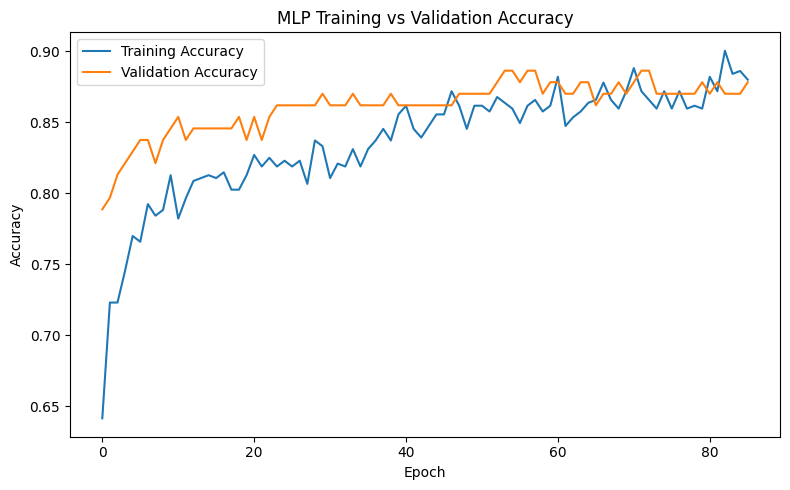

In [50]:
# ============================================================
# MLP TRAINING / VALIDATION PERFORMANCE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    mlp_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mlp_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MLP Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

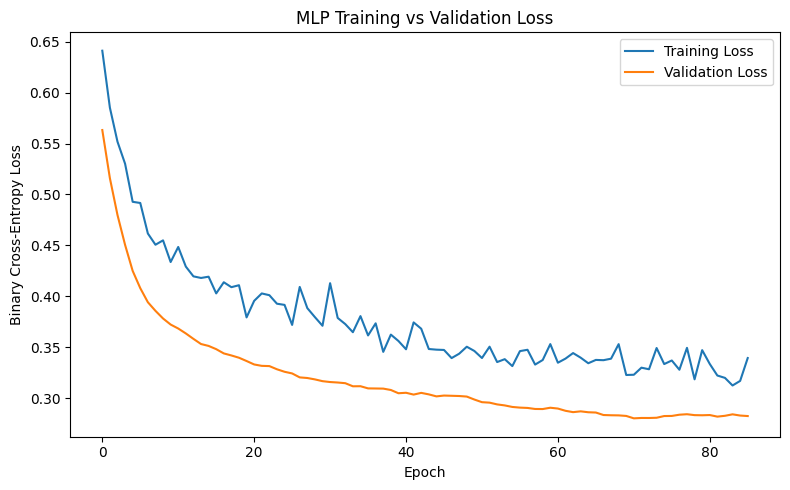

In [51]:
# ============================================================
# MLP LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    mlp_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mlp_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MLP Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# MLP VALIDATION EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import time

# Start timing
start_time = time.time()

# Probability predictions
mlp_val_prob = mlp_model.predict(
    X_val_scaled,
    verbose=0
).ravel()

# Convert probabilities to classes
mlp_val_pred = (mlp_val_prob >= 0.5).astype(int)

mlp_training_time = time.time() - start_time

# Metrics
mlp_accuracy = accuracy_score(y_val, mlp_val_pred)
mlp_precision = precision_score(y_val, mlp_val_pred)
mlp_recall = recall_score(y_val, mlp_val_pred)
mlp_f1 = f1_score(y_val, mlp_val_pred)
mlp_roc_auc = roc_auc_score(y_val, mlp_val_prob)

print("MLP Validation Performance")
print("=" * 50)
print(f"Accuracy  : {mlp_accuracy:.4f}")
print(f"Precision : {mlp_precision:.4f}")
print(f"Recall    : {mlp_recall:.4f}")
print(f"F1-Score  : {mlp_f1:.4f}")
print(f"ROC-AUC   : {mlp_roc_auc:.4f}")
print(f"Time      : {mlp_training_time:.4f} seconds")

MLP Validation Performance
Accuracy  : 0.8780
Precision : 0.7917
Recall    : 0.8837
F1-Score  : 0.8352
ROC-AUC   : 0.9512
Time      : 0.1564 seconds


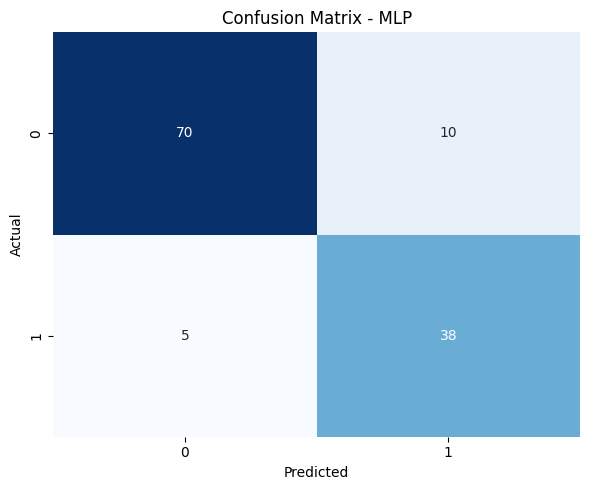

In [53]:
# ============================================================
# MLP CONFUSION MATRIX
# ============================================================

mlp_cm = confusion_matrix(y_val, mlp_val_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    mlp_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix - MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# ADD MLP TO MODEL COMPARISON
# ============================================================

# Add MLP results to the existing baseline results
all_model_results = baseline_results.copy()

all_model_results["Multilayer Perceptron"] = {
    "Accuracy": mlp_accuracy,
    "Precision": mlp_precision,
    "Recall": mlp_recall,
    "F1": mlp_f1,
    "ROC-AUC": mlp_roc_auc,
    "Confusion Matrix": mlp_cm,
    "Training Time": mlp_training_time
}

# ------------------------------------------------------------
# CREATE COMPARISON TABLE
# ------------------------------------------------------------

comparison_rows = []

for name, result in all_model_results.items():

    # Handle either possible training-time key
    training_time = result.get(
        "Training Time",
        result.get("Training Time (s)", np.nan)
    )

    comparison_rows.append({
        "Model": name,
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1": result["F1"],
        "ROC-AUC": result["ROC-AUC"],
        "Training Time (s)": training_time
    })

comparison_df = pd.DataFrame(comparison_rows)

# Sort by ROC-AUC
comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

# Display results
display(comparison_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Gradient Boosting,0.8862,0.7843,0.9302,0.8511,0.9672,0.2381
1,Random Forest,0.9024,0.8039,0.9535,0.8723,0.9592,0.6249
2,Multilayer Perceptron,0.8780,0.7917,0.8837,0.8352,0.9512,0.1564
3,Support Vector Machine,0.8780,0.7917,0.8837,0.8352,0.9422,0.0679
4,Logistic Regression,0.8293,0.8235,0.6512,0.7273,0.9096,0.0121
5,K-Nearest Neighbors,0.8455,0.7857,0.7674,0.7765,0.9023,0.0043
6,Decision Tree,0.8130,0.6923,0.8372,0.7579,0.8186,0.0074


In [55]:
# ============================================================
# DEEP MLP
# ============================================================

from tensorflow import keras
from tensorflow.keras import layers, regularizers

deep_mlp = keras.Sequential([

    layers.Input(shape=(X_train_scaled.shape[1],)),

    # Hidden Layer 1
    layers.Dense(64, activation="relu"),

    # Hidden Layer 2
    layers.Dense(32, activation="relu"),

    # Hidden Layer 3
    layers.Dense(16, activation="relu"),

    # Output Layer
    layers.Dense(1, activation="sigmoid")
])

deep_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

deep_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# ============================================================
# TRAIN DEEP MLP
# ============================================================

deep_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

deep_history = deep_mlp.fit(
    X_train_scaled,
    y_train,

    validation_data=(X_val_scaled, y_val),

    epochs=150,
    batch_size=32,

    callbacks=[deep_early_stopping],

    verbose=1
)

print("Deep MLP training completed.")

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7088 - loss: 0.6189 - precision: 0.7000 - recall: 0.2865 - val_accuracy: 0.7886 - val_loss: 0.5474 - val_precision: 0.7931 - val_recall: 0.5349
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7637 - loss: 0.5222 - precision: 0.7723 - recall: 0.4561 - val_accuracy: 0.8293 - val_loss: 0.4660 - val_precision: 0.8667 - val_recall: 0.6047
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7841 - loss: 0.4650 - precision: 0.7642 - recall: 0.5497 - val_accuracy: 0.8130 - val_loss: 0.4174 - val_precision: 0.8125 - val_recall: 0.6047
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7862 - loss: 0.4322 - precision: 0.7391 - recall: 0.5965 - val_accuracy: 0.8293 - val_loss: 0.3857 - val_precision: 0.8235 - val_recall: 0.6512
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8024 - loss: 0.4108 - precision: 0.7434 - recall: 0.6608 - val_accuracy: 0.8293 - val_loss: 0.3742

In [57]:
# ============================================================
# DEEP MLP VALIDATION EVALUATION
# ============================================================

start_time = time.time()

deep_val_prob = deep_mlp.predict(
    X_val_scaled,
    verbose=0
).ravel()

deep_val_pred = (deep_val_prob >= 0.5).astype(int)

deep_time = time.time() - start_time

deep_accuracy = accuracy_score(y_val, deep_val_pred)
deep_precision = precision_score(y_val, deep_val_pred)
deep_recall = recall_score(y_val, deep_val_pred)
deep_f1 = f1_score(y_val, deep_val_pred)
deep_roc_auc = roc_auc_score(y_val, deep_val_prob)

deep_cm = confusion_matrix(y_val, deep_val_pred)

print("Deep MLP Validation Performance")
print("=" * 50)
print(f"Accuracy  : {deep_accuracy:.4f}")
print(f"Precision : {deep_precision:.4f}")
print(f"Recall    : {deep_recall:.4f}")
print(f"F1-Score  : {deep_f1:.4f}")
print(f"ROC-AUC   : {deep_roc_auc:.4f}")
print(f"Time      : {deep_time:.4f} seconds")

Deep MLP Validation Performance
Accuracy  : 0.8943
Precision : 0.8125
Recall    : 0.9070
F1-Score  : 0.8571
ROC-AUC   : 0.9462
Time      : 0.1726 seconds


In [58]:
# ============================================================
# REGULARIZED DEEP MLP
# ============================================================

regularized_mlp = keras.Sequential([

    layers.Input(shape=(X_train_scaled.shape[1],)),

    # Hidden Layer 1
    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.30),

    # Hidden Layer 2
    layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.25),

    # Hidden Layer 3
    layers.Dense(
        16,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    # Output
    layers.Dense(1, activation="sigmoid")
])

regularized_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

regularized_mlp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
# ============================================================
# TRAIN REGULARIZED MLP
# ============================================================

regularized_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

regularized_history = regularized_mlp.fit(
    X_train_scaled,
    y_train,

    validation_data=(X_val_scaled, y_val),

    epochs=150,
    batch_size=32,

    callbacks=[regularized_early_stopping],

    verbose=1
)

print("Regularized MLP training completed.")

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5988 - loss: 0.7403 - precision: 0.3452 - recall: 0.1696 - val_accuracy: 0.6911 - val_loss: 0.6488 - val_precision: 0.8571 - val_recall: 0.1395
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6864 - loss: 0.6572 - precision: 0.7576 - recall: 0.1462 - val_accuracy: 0.7236 - val_loss: 0.5846 - val_precision: 0.9091 - val_recall: 0.2326
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6802 - loss: 0.6358 - precision: 0.6591 - recall: 0.1696 - val_accuracy: 0.7724 - val_loss: 0.5440 - val_precision: 0.8571 - val_recall: 0.4186
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7189 - loss: 0.6066 - precision: 0.7324 - recall: 0.3041 - val_accuracy: 0.8049 - val_loss: 0.5117 - val_precision: 0.8519 - val_recall: 0.5349
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7495 - loss: 0.5760 - precision: 0.7353 - recall: 0.4386 - val_accuracy: 0.8374 - val_loss: 0.4902

In [60]:
# ============================================================
# REGULARIZED MLP VALIDATION EVALUATION
# ============================================================

start_time = time.time()

reg_val_prob = regularized_mlp.predict(
    X_val_scaled,
    verbose=0
).ravel()

reg_val_pred = (reg_val_prob >= 0.5).astype(int)

reg_time = time.time() - start_time

reg_accuracy = accuracy_score(y_val, reg_val_pred)
reg_precision = precision_score(y_val, reg_val_pred)
reg_recall = recall_score(y_val, reg_val_pred)
reg_f1 = f1_score(y_val, reg_val_pred)
reg_roc_auc = roc_auc_score(y_val, reg_val_prob)

reg_cm = confusion_matrix(y_val, reg_val_pred)

print("Regularized MLP Validation Performance")
print("=" * 50)
print(f"Accuracy  : {reg_accuracy:.4f}")
print(f"Precision : {reg_precision:.4f}")
print(f"Recall    : {reg_recall:.4f}")
print(f"F1-Score  : {reg_f1:.4f}")
print(f"ROC-AUC   : {reg_roc_auc:.4f}")
print(f"Time      : {reg_time:.4f} seconds")

Regularized MLP Validation Performance
Accuracy  : 0.8699
Precision : 0.8000
Recall    : 0.8372
F1-Score  : 0.8182
ROC-AUC   : 0.9558
Time      : 0.1645 seconds


In [61]:
# ============================================================
# BATCH-NORMALIZED MLP
# ============================================================

batchnorm_mlp = keras.Sequential([

    layers.Input(shape=(X_train_scaled.shape[1],)),

    # Hidden Layer 1
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    # Hidden Layer 2
    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    # Hidden Layer 3
    layers.Dense(16),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    # Output
    layers.Dense(1, activation="sigmoid")
])

batchnorm_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

batchnorm_mlp.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,425 (13.38 KB)

 Non-trainable params: 224 (896.00 B)

In [62]:
# ============================================================
# TRAIN BATCH-NORMALIZED MLP
# ============================================================

batchnorm_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

batchnorm_history = batchnorm_mlp.fit(
    X_train_scaled,
    y_train,

    validation_data=(X_val_scaled, y_val),

    epochs=150,
    batch_size=32,

    callbacks=[batchnorm_early_stopping],

    verbose=1
)

print("Batch-Normalized MLP training completed.")

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7067 - loss: 0.5653 - precision: 0.6552 - recall: 0.3333 - val_accuracy: 0.7724 - val_loss: 0.6276 - val_precision: 0.6415 - val_recall: 0.7907
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8024 - loss: 0.4665 - precision: 0.8136 - recall: 0.5614 - val_accuracy: 0.8537 - val_loss: 0.5723 - val_precision: 0.7660 - val_recall: 0.8372
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7984 - loss: 0.4334 - precision: 0.7687 - recall: 0.6023 - val_accuracy: 0.8455 - val_loss: 0.5225 - val_precision: 0.7857 - val_recall: 0.7674
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8167 - loss: 0.4256 - precision: 0.7793 - recall: 0.6608 - val_accuracy: 0.8374 - val_loss: 0.4818 - val_precision: 0.8286 - val_recall: 0.6744
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8534 - loss: 0.4005 - precision: 0.8367 - recall: 0.7193 - val_accuracy: 0.8374 - val_loss: 0.4450

In [63]:
# ============================================================
# BATCH-NORMALIZED MLP VALIDATION EVALUATION
# ============================================================

start_time = time.time()

bn_val_prob = batchnorm_mlp.predict(
    X_val_scaled,
    verbose=0
).ravel()

bn_val_pred = (bn_val_prob >= 0.5).astype(int)

bn_time = time.time() - start_time

bn_accuracy = accuracy_score(y_val, bn_val_pred)
bn_precision = precision_score(y_val, bn_val_pred)
bn_recall = recall_score(y_val, bn_val_pred)
bn_f1 = f1_score(y_val, bn_val_pred)
bn_roc_auc = roc_auc_score(y_val, bn_val_prob)

bn_cm = confusion_matrix(y_val, bn_val_pred)

print("Batch-Normalized MLP Validation Performance")
print("=" * 50)
print(f"Accuracy  : {bn_accuracy:.4f}")
print(f"Precision : {bn_precision:.4f}")
print(f"Recall    : {bn_recall:.4f}")
print(f"F1-Score  : {bn_f1:.4f}")
print(f"ROC-AUC   : {bn_roc_auc:.4f}")
print(f"Time      : {bn_time:.4f} seconds")

Batch-Normalized MLP Validation Performance
Accuracy  : 0.8862
Precision : 0.8222
Recall    : 0.8605
F1-Score  : 0.8409
ROC-AUC   : 0.9442
Time      : 0.2599 seconds


In [64]:
# ============================================================
# NEURAL NETWORK MODEL COMPARISON
# ============================================================

neural_results = pd.DataFrame([

    {
        "Model": "Standard MLP",
        "Accuracy": mlp_accuracy,
        "Precision": mlp_precision,
        "Recall": mlp_recall,
        "F1": mlp_f1,
        "ROC-AUC": mlp_roc_auc,
        "Training Time (s)": mlp_training_time
    },

    {
        "Model": "Deep MLP",
        "Accuracy": deep_accuracy,
        "Precision": deep_precision,
        "Recall": deep_recall,
        "F1": deep_f1,
        "ROC-AUC": deep_roc_auc,
        "Training Time (s)": deep_time
    },

    {
        "Model": "Regularized Deep MLP",
        "Accuracy": reg_accuracy,
        "Precision": reg_precision,
        "Recall": reg_recall,
        "F1": reg_f1,
        "ROC-AUC": reg_roc_auc,
        "Training Time (s)": reg_time
    },

    {
        "Model": "Batch-Normalized MLP",
        "Accuracy": bn_accuracy,
        "Precision": bn_precision,
        "Recall": bn_recall,
        "F1": bn_f1,
        "ROC-AUC": bn_roc_auc,
        "Training Time (s)": bn_time
    }
])

# Sort according to ROC-AUC
neural_results = neural_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(neural_results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Regularized Deep MLP,0.8699,0.8000,0.8372,0.8182,0.9558,0.1645
1,Standard MLP,0.8780,0.7917,0.8837,0.8352,0.9512,0.1564
2,Deep MLP,0.8943,0.8125,0.9070,0.8571,0.9462,0.1726
3,Batch-Normalized MLP,0.8862,0.8222,0.8605,0.8409,0.9442,0.2599


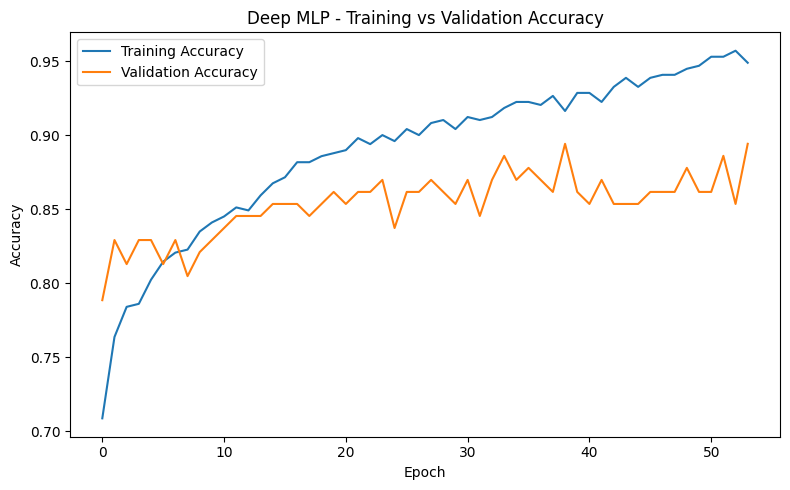

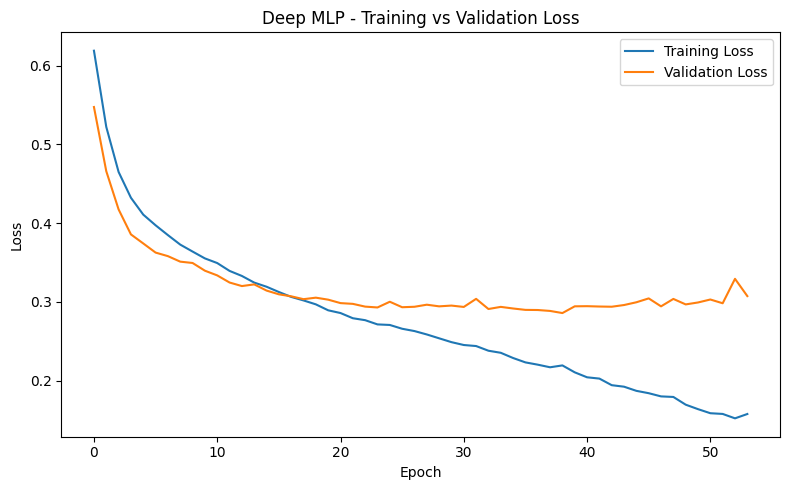

In [65]:
# ============================================================
# DEEP MLP - TRAINING VS VALIDATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    deep_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    deep_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Deep MLP - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    deep_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    deep_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Deep MLP - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
# ============================================================
# COMPLETE MODEL COMPARISON
# ============================================================

# Traditional ML results + Neural Network results

all_results = []

# ------------------------------------------------------------
# TRADITIONAL ML MODELS
# ------------------------------------------------------------

for name, result in baseline_results.items():

    training_time = result.get(
        "Training Time",
        result.get("Training Time (s)", np.nan)
    )

    all_results.append({
        "Model": name,
        "Type": "Machine Learning",
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1": result["F1"],
        "ROC-AUC": result["ROC-AUC"],
        "Training Time (s)": training_time
    })


# ------------------------------------------------------------
# NEURAL NETWORK MODELS
# ------------------------------------------------------------

neural_rows = [
    {
        "Model": "Standard MLP",
        "Type": "Deep Learning",
        "Accuracy": mlp_accuracy,
        "Precision": mlp_precision,
        "Recall": mlp_recall,
        "F1": mlp_f1,
        "ROC-AUC": mlp_roc_auc,
        "Training Time (s)": mlp_training_time
    },
    {
        "Model": "Deep MLP",
        "Type": "Deep Learning",
        "Accuracy": deep_accuracy,
        "Precision": deep_precision,
        "Recall": deep_recall,
        "F1": deep_f1,
        "ROC-AUC": deep_roc_auc,
        "Training Time (s)": deep_time
    },
    {
        "Model": "Regularized Deep MLP",
        "Type": "Deep Learning",
        "Accuracy": reg_accuracy,
        "Precision": reg_precision,
        "Recall": reg_recall,
        "F1": reg_f1,
        "ROC-AUC": reg_roc_auc,
        "Training Time (s)": reg_time
    },
    {
        "Model": "Batch-Normalized MLP",
        "Type": "Deep Learning",
        "Accuracy": bn_accuracy,
        "Precision": bn_precision,
        "Recall": bn_recall,
        "F1": bn_f1,
        "ROC-AUC": bn_roc_auc,
        "Training Time (s)": bn_time
    }
]

all_results.extend(neural_rows)

# ------------------------------------------------------------
# FINAL COMPARISON TABLE
# ------------------------------------------------------------

all_models_df = pd.DataFrame(all_results)

all_models_df = all_models_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(all_models_df.round(4))

,Model,Type,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Gradient Boosting,Machine Learning,0.8862,0.7843,0.9302,0.8511,0.9672,0.2381
1,Random Forest,Machine Learning,0.9024,0.8039,0.9535,0.8723,0.9592,0.6249
2,Regularized Deep MLP,Deep Learning,0.8699,0.8000,0.8372,0.8182,0.9558,0.1645
3,Standard MLP,Deep Learning,0.8780,0.7917,0.8837,0.8352,0.9512,0.1564
4,Deep MLP,Deep Learning,0.8943,0.8125,0.9070,0.8571,0.9462,0.1726
5,Batch-Normalized MLP,Deep Learning,0.8862,0.8222,0.8605,0.8409,0.9442,0.2599
6,Support Vector Machine,Machine Learning,0.8780,0.7917,0.8837,0.8352,0.9422,0.0679
7,Logistic Regression,Machine Learning,0.8293,0.8235,0.6512,0.7273,0.9096,0.0121
8,K-Nearest Neighbors,Machine Learning,0.8455,0.7857,0.7674,0.7765,0.9023,0.0043
9,Decision Tree,Machine Learning,0.8130,0.6923,0.8372,0.7579,0.8186,0.0074


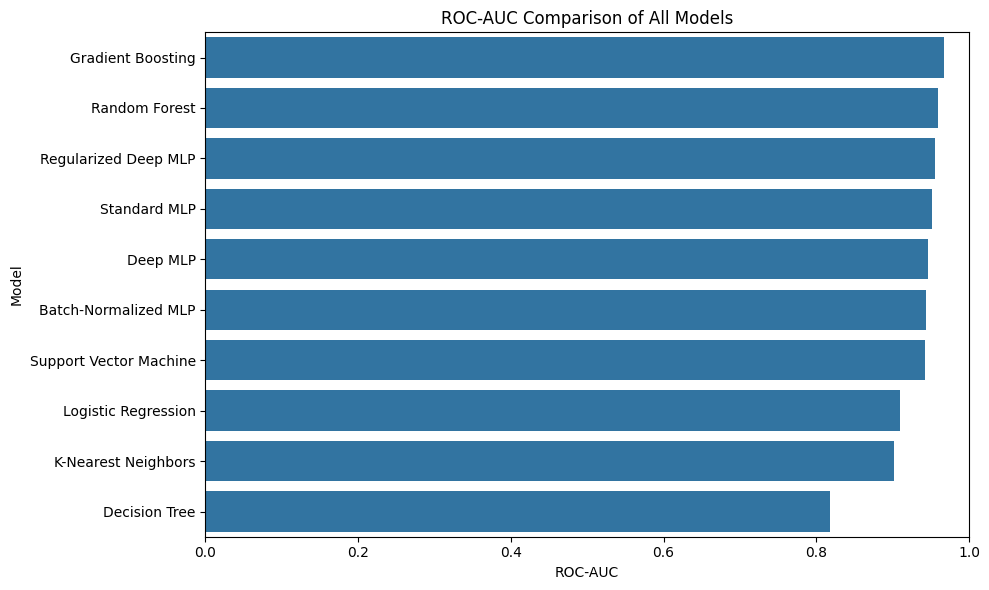

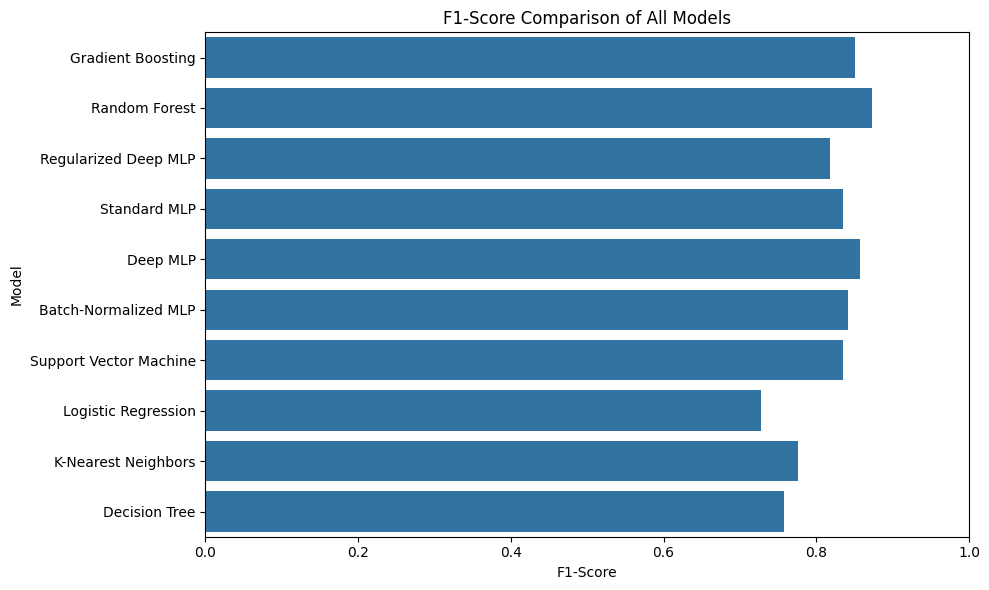

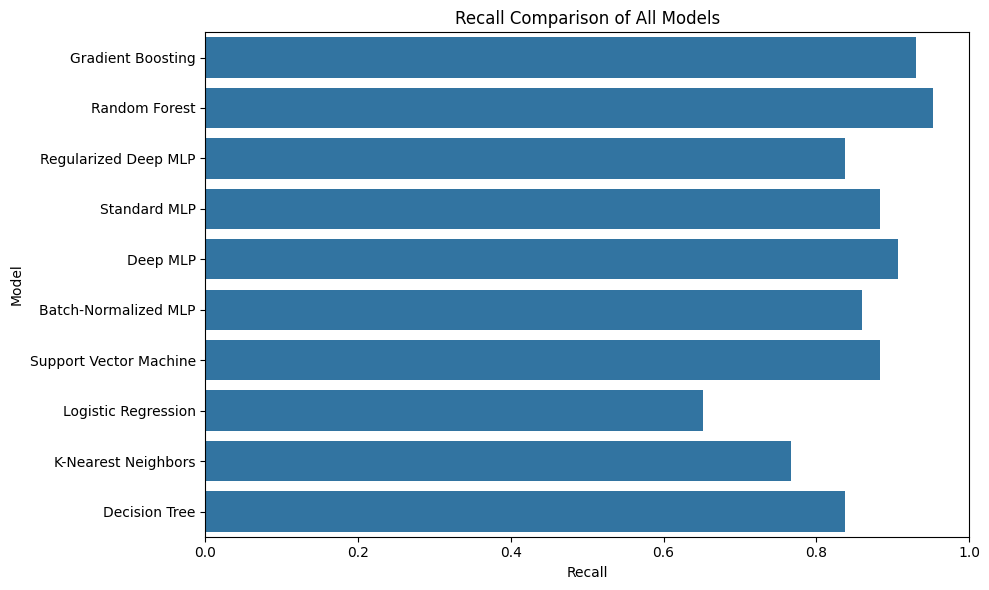

In [67]:
# ============================================================
# ROC-AUC MODEL COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=all_models_df,
    x="ROC-AUC",
    y="Model"
)

plt.title("ROC-AUC Comparison of All Models")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()



# ============================================================
# F1-SCORE MODEL COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=all_models_df,
    x="F1",
    y="Model"
)

plt.title("F1-Score Comparison of All Models")
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# ============================================================
# RECALL MODEL COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=all_models_df,
    x="Recall",
    y="Model"
)

plt.title("Recall Comparison of All Models")
plt.xlabel("Recall")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [68]:
# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

# ------------------------------------------------------------
# 1. RANDOM FOREST
# ------------------------------------------------------------

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE
    ),
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_scaled, y_train)

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)

print(f"Best CV ROC-AUC: {rf_grid.best_score_:.4f}")

HYPERPARAMETER TUNING
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Random Forest Parameters:
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best CV ROC-AUC: 0.9394


In [69]:
# ------------------------------------------------------------
# 2. MULTILAYER PERCEPTRON (MLP)
# ------------------------------------------------------------

mlp_param_grid = {
    "hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32),
        (128, 64)
    ],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "batch_size": [16, 32],
    "max_iter": [500]
}

mlp_grid = GridSearchCV(
    estimator=MLPClassifier(
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.15
    ),
    param_grid=mlp_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

mlp_grid.fit(X_train_scaled, y_train)

print("\nBest MLP Parameters:")
print(mlp_grid.best_params_)

print(f"Best CV ROC-AUC: {mlp_grid.best_score_:.4f}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best MLP Parameters:
{'activation': 'tanh', 'alpha': 0.0001, 'batch_size': 16, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01, 'max_iter': 500}
Best CV ROC-AUC: 0.9187


In [70]:
# ============================================================
# VALIDATION PERFORMANCE OF TUNED MODELS
# ============================================================

tuned_models = {
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned MLP": mlp_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():

    y_val_pred = model.predict(X_val_scaled)
    y_val_prob = model.predict_proba(X_val_scaled)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1": f1_score(y_val, y_val_pred),
        "ROC-AUC": roc_auc_score(y_val, y_val_prob)
    })

tuned_results_df = pd.DataFrame(tuned_results)

display(
    tuned_results_df
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Random Forest,0.9106,0.82,0.9535,0.8817,0.966
1,Tuned MLP,0.8618,0.75,0.9070,0.8211,0.948


In [71]:
# ============================================================
# AUTOMATIC BEST MODEL SELECTION
# ============================================================

# Combine baseline and tuned model results
all_validation_results = pd.concat(
    [
        comparison_df,
        tuned_results_df
    ],
    ignore_index=True
)

# Sort primarily by ROC-AUC, then F1
all_validation_results = (
    all_validation_results
    .sort_values(
        by=["ROC-AUC", "F1"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("ALL MODEL VALIDATION RESULTS")
print("=" * 70)

display(all_validation_results.round(4))

# Select best model
best_model_name = all_validation_results.loc[0, "Model"]

print("\n" + "=" * 70)
print("BEST MODEL SELECTED")
print("=" * 70)
print(f"Model: {best_model_name}")
print(f"ROC-AUC: {all_validation_results.loc[0, 'ROC-AUC']:.4f}")
print(f"F1-Score: {all_validation_results.loc[0, 'F1']:.4f}")
print(f"Accuracy: {all_validation_results.loc[0, 'Accuracy']:.4f}")

ALL MODEL VALIDATION RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Gradient Boosting,0.8862,0.7843,0.9302,0.8511,0.9672,0.2381
1,Tuned Random Forest,0.9106,0.8200,0.9535,0.8817,0.9660,NaN
2,Random Forest,0.9024,0.8039,0.9535,0.8723,0.9592,0.6249
3,Multilayer Perceptron,0.8780,0.7917,0.8837,0.8352,0.9512,0.1564
4,Tuned MLP,0.8618,0.7500,0.9070,0.8211,0.9480,NaN
5,Support Vector Machine,0.8780,0.7917,0.8837,0.8352,0.9422,0.0679
6,Logistic Regression,0.8293,0.8235,0.6512,0.7273,0.9096,0.0121
7,K-Nearest Neighbors,0.8455,0.7857,0.7674,0.7765,0.9023,0.0043
8,Decision Tree,0.8130,0.6923,0.8372,0.7579,0.8186,0.0074



BEST MODEL SELECTED
Model: Gradient Boosting
ROC-AUC: 0.9672
F1-Score: 0.8511
Accuracy: 0.8862


In [72]:
# ============================================================
# AUTOMATIC BEST MODEL SELECTION
# ============================================================

# We prioritize F1-Score because it balances
# Precision and Recall, while ROC-AUC is used as
# the secondary criterion.

all_validation_results = pd.concat(
    [
        comparison_df,
        tuned_results_df
    ],
    ignore_index=True
)

all_validation_results = (
    all_validation_results
    .sort_values(
        by=["F1", "ROC-AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("ALL MODEL VALIDATION RESULTS")
print("=" * 70)

display(all_validation_results.round(4))

# ------------------------------------------------------------
# SELECT BEST MODEL
# ------------------------------------------------------------

best_model_name = all_validation_results.loc[0, "Model"]

print("\n" + "=" * 70)
print("BEST MODEL SELECTED")
print("=" * 70)

print(f"Model      : {best_model_name}")
print(f"Accuracy   : {all_validation_results.loc[0, 'Accuracy']:.4f}")
print(f"Precision  : {all_validation_results.loc[0, 'Precision']:.4f}")
print(f"Recall     : {all_validation_results.loc[0, 'Recall']:.4f}")
print(f"F1-Score   : {all_validation_results.loc[0, 'F1']:.4f}")
print(f"ROC-AUC    : {all_validation_results.loc[0, 'ROC-AUC']:.4f}")

ALL MODEL VALIDATION RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Tuned Random Forest,0.9106,0.8200,0.9535,0.8817,0.9660,NaN
1,Random Forest,0.9024,0.8039,0.9535,0.8723,0.9592,0.6249
2,Gradient Boosting,0.8862,0.7843,0.9302,0.8511,0.9672,0.2381
3,Multilayer Perceptron,0.8780,0.7917,0.8837,0.8352,0.9512,0.1564
4,Support Vector Machine,0.8780,0.7917,0.8837,0.8352,0.9422,0.0679
5,Tuned MLP,0.8618,0.7500,0.9070,0.8211,0.9480,NaN
6,K-Nearest Neighbors,0.8455,0.7857,0.7674,0.7765,0.9023,0.0043
7,Decision Tree,0.8130,0.6923,0.8372,0.7579,0.8186,0.0074
8,Logistic Regression,0.8293,0.8235,0.6512,0.7273,0.9096,0.0121



BEST MODEL SELECTED
Model      : Tuned Random Forest
Accuracy   : 0.9106
Precision  : 0.8200
Recall     : 0.9535
F1-Score   : 0.8817
ROC-AUC    : 0.9660


In [73]:
# ============================================================
# FINAL MODEL TRAINING DATA
# COMBINE TRAINING + VALIDATION SET
# ============================================================

print("=" * 70)
print("PREPARING FINAL TRAINING DATA")
print("=" * 70)

# Combine training and validation datasets
X_train_final = pd.concat(
    [X_train_scaled, X_val_scaled],
    axis=0
)

y_train_final = pd.concat(
    [y_train, y_val],
    axis=0
)

print(f"Original training samples   : {len(X_train_scaled)}")
print(f"Validation samples           : {len(X_val_scaled)}")
print(f"Final training samples       : {len(X_train_final)}")
print(f"Test samples                 : {len(X_test_scaled)}")

print("\nFinal training feature shape:")
print(X_train_final.shape)

print("\nTest feature shape:")
print(X_test_scaled.shape)

PREPARING FINAL TRAINING DATA
Original training samples   : 491
Validation samples           : 123
Final training samples       : 614
Test samples                 : 154

Final training feature shape:
(614, 8)

Test feature shape:
(154, 8)


In [74]:
# ============================================================
# TRAIN FINAL TUNED RANDOM FOREST
# ============================================================

final_model = RandomForestClassifier(
    **rf_grid.best_params_,
    random_state=RANDOM_STATE
)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

# Train on combined Training + Validation data
final_model.fit(
    X_train_final,
    y_train_final
)

print("\nFinal model trained successfully.")

Best Random Forest Parameters:
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}

Final model trained successfully.


In [75]:
# ============================================================
# FINAL MODEL — TEST SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("FINAL MODEL EVALUATION ON TEST SET")
print("=" * 70)

# Predictions
y_test_pred = final_model.predict(X_test_scaled)

# Probability predictions
y_test_prob = final_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
final_accuracy = accuracy_score(y_test, y_test_pred)
final_precision = precision_score(y_test, y_test_pred)
final_recall = recall_score(y_test, y_test_pred)
final_f1 = f1_score(y_test, y_test_pred)
final_roc_auc = roc_auc_score(y_test, y_test_prob)

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1-Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

FINAL MODEL EVALUATION ON TEST SET
Accuracy  : 0.8636
Precision : 0.8113
Recall    : 0.7963
F1-Score  : 0.8037
ROC-AUC   : 0.9491


In [76]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Non-Diabetic", "Diabetic"]
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Non-Diabetic       0.89      0.90      0.90       100
    Diabetic       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



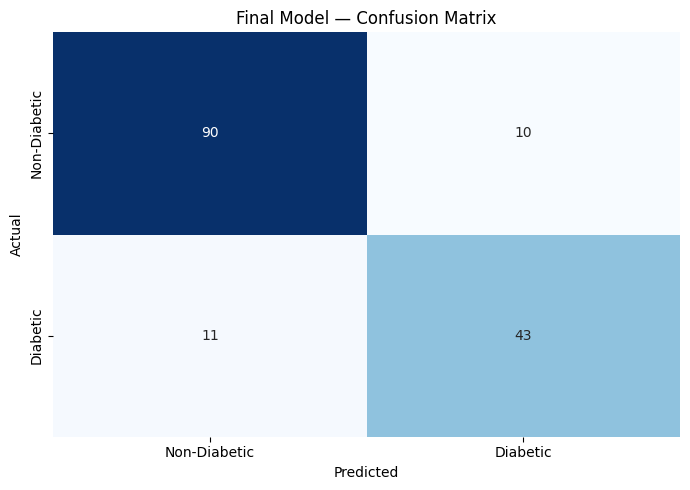

In [77]:
# ============================================================
# CONFUSION MATRIX — FINAL MODEL
# ============================================================

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.title("Final Model — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

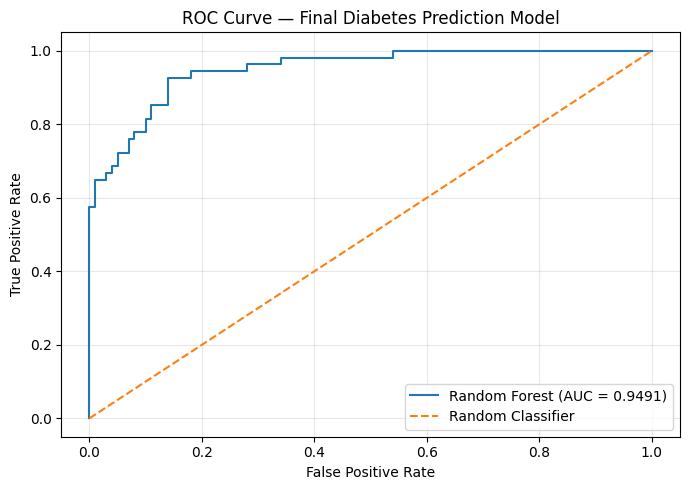

In [78]:
# ============================================================
# ROC CURVE — FINAL MODEL
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {final_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Diabetes Prediction Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:
# ============================================================
# FINAL MODEL — FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("=" * 70)
print("FINAL MODEL — FEATURE IMPORTANCE")
print("=" * 70)

display(feature_importance.round(4))

FINAL MODEL — FEATURE IMPORTANCE


,Feature,Importance
0,Insulin,0.4899
1,Glucose,0.1744
2,SkinThickness,0.1308
3,Age,0.0626
4,BMI,0.0547
5,DiabetesPedigreeFunction,0.0388
6,BloodPressure,0.0248
7,Pregnancies,0.0239


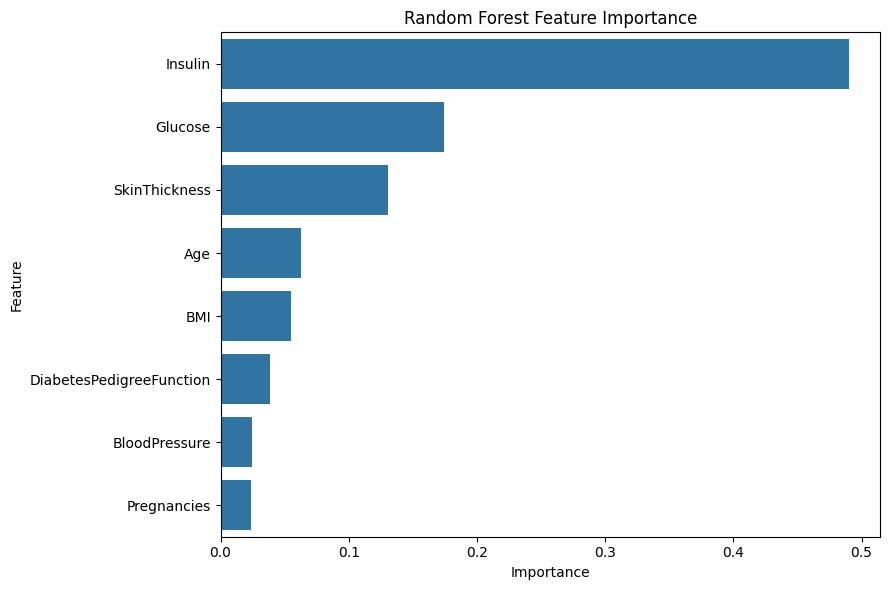

In [80]:
# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [81]:
# ============================================================
# SAVE FINAL MODEL AND PREPROCESSING OBJECT
# ============================================================

import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save final trained Random Forest
model_path = "../models/final_random_forest.pkl"
joblib.dump(final_model, model_path)

# Save the scaler used during preprocessing
scaler_path = "../models/standard_scaler.pkl"
joblib.dump(scaler, scaler_path)

print("=" * 70)
print("MODEL SAVING")
print("=" * 70)
print(f"Final model saved to : {model_path}")
print(f"Scaler saved to      : {scaler_path}")
print("Model and scaler saved successfully.")

MODEL SAVING
Final model saved to : ../models/final_random_forest.pkl
Scaler saved to      : ../models/standard_scaler.pkl
Model and scaler saved successfully.


In [82]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

import joblib
import os

model_path = "../models/final_random_forest.pkl"
scaler_path = "../models/standard_scaler.pkl"

# Load saved objects
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

print("=" * 70)
print("SAVED MODEL VERIFICATION")
print("=" * 70)

print("Model loaded successfully :", type(loaded_model).__name__)
print("Scaler loaded successfully:", type(loaded_scaler).__name__)

# Verify prediction capability
sample_prediction = loaded_model.predict(X_test_scaled[:5])

print("\nSample predictions:", sample_prediction)
print("Verification completed successfully.")

SAVED MODEL VERIFICATION
Model loaded successfully : RandomForestClassifier
Scaler loaded successfully: StandardScaler

Sample predictions: [0 0 0 1 0]
Verification completed successfully.


In [83]:
import os

print(os.path.abspath("../models/final_random_forest.pkl"))
print(os.path.abspath("../models/standard_scaler.pkl"))

/models/final_random_forest.pkl
/models/standard_scaler.pkl


In [84]:
from google.colab import files

files.download("../models/final_random_forest.pkl")
files.download("../models/standard_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>